<a href="https://colab.research.google.com/github/Bebarzzz/machine-/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

In [6]:
df = pd.read_csv('/Chronotype_NHANES_Imputation1.csv')
df.head()



,Seqn,Gender,Age,Race,BMI,Waist_C,Systolic,Diastolic,Carb_diet,HSCRP,Smokingstatus,Alcohol,Sleep_hrs,Sleeptime,Wakeuptime,Chronotype_slphrs,WakeUpCat
0,83732,1,62,2.0,27.8,101.1,122.6667,65.33334,126.0,0.6,3.0,1.0,5.5,23:30:00,05:00:00,3.0,1
1,83733,1,53,2.0,30.8,107.9,140.0000,86.00000,126.0,1.4,1.0,7.0,8.0,23:00:00,07:00:00,3.0,3
2,83734,1,78,2.0,28.8,116.5,135.3333,45.33333,96.0,0.6,3.0,0.0,7.0,22:30:00,05:30:00,2.0,2
3,83735,2,56,2.0,42.4,110.1,134.0000,70.00000,216.0,9.0,3.0,3.0,6.5,23:30:00,06:00:00,3.0,2
4,83741,1,22,3.0,28.0,86.6,111.3333,72.66666,5.5,1.3,2.0,3.0,6.5,23:00:00,05:30:00,3.0,2


### Data Preparation
We need to separate the target variable `Chronotype_slphrs` from the features. We should also remove identifiers like `Seqn` and non-numeric time columns that aren't ready for modeling.

In [23]:
# 1. Apply Winsorization (Clipping) to handle outliers
def handle_outliers(df_in, columns):
    df_out = df_in.copy()
    for col in columns:
        lower = df_out[col].quantile(0.01)
        upper = df_out[col].quantile(0.99)
        df_out[col] = df_out[col].clip(lower, upper)
    return df_out

numeric_features = ['Age', 'BMI', 'Waist_C', 'Systolic', 'Diastolic', 'Carb_diet', 'HSCRP', 'Alcohol', 'Sleep_hrs']
df_cleaned = handle_outliers(df, numeric_features)

# 2. Define features and target using clipped data, removing 'Race'
X = df_cleaned.drop(columns=['Chronotype_slphrs', 'Seqn', 'Sleeptime', 'Wakeuptime', 'Gender', 'Smokingstatus', 'Race'])
y = df_cleaned['Chronotype_slphrs']

# 3. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Outliers clipped at 1st/99th percentile for: {numeric_features}")
print(f"Training set shape: {X_train.shape}")

Outliers clipped at 1st/99th percentile for: ['Age', 'BMI', 'Waist_C', 'Systolic', 'Diastolic', 'Carb_diet', 'HSCRP', 'Alcohol', 'Sleep_hrs']
Training set shape: (4469, 10)


### Model Training and Evaluation
Now we initialize and fit the Random Forest Classifier.

In [8]:
# Re-training Random Forest with reduced features
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print("RF Accuracy (Cleaned Features):", accuracy_score(y_test, y_pred))

RF Accuracy (Cleaned Features): 0.7495527728085868


### XGBoost Classifier
Next, we'll try the XGBoost model. First, we need to import it and then train it using our prepared features and target.

In [9]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost often requires label encoding for targets starting from 0
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Initialize the XGBoost model (removed deprecated use_label_encoder)
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')

# Fit the model
xgb_model.fit(X_train, y_train_encoded)

# Make predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluation
print("XGBoost Accuracy Score:", accuracy_score(y_test_encoded, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred_xgb, target_names=le.classes_.astype(str)))

XGBoost Accuracy Score: 0.740608228980322

Classification Report:
              precision    recall  f1-score   support

         1.0       0.67      0.49      0.57       156
         2.0       0.71      0.72      0.72       344
         3.0       0.78      0.88      0.83       443
         4.0       0.70      0.66      0.68        74
         5.0       0.72      0.66      0.69       101

    accuracy                           0.74      1118
   macro avg       0.72      0.68      0.70      1118
weighted avg       0.74      0.74      0.73      1118



### Neural Network Hyperparameter Tuning with Keras Tuner

We will now use `keras_tuner` to perform a more extensive hyperparameter search for our Neural Network model. This allows us to systematically explore different architectures and training parameters to find the best performing model. The goal is to maximize the validation accuracy.

In [10]:
# Install Keras Tuner if not already installed
import subprocess
import sys

try:
    import keras_tuner
except ImportError:
    print("Installing Keras Tuner...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "keras-tuner"])
    import keras_tuner

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

print("Keras Tuner and TensorFlow imported successfully.")

Installing Keras Tuner...
Keras Tuner and TensorFlow imported successfully.


In [24]:
# Scale features for Neural Networks and SVM
scaler = StandardScaler()
X_train_nn_scaled = scaler.fit_transform(X_train)
X_test_nn_scaled = scaler.transform(X_test)

# Get number of classes for the output layer
num_classes = len(np.unique(y_train_encoded))

# Define the Keras Tuner model building function
def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_nn_scaled.shape[1],)))

    # Tune the number of layers
    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(layers.Dense(units=hp.Int('units_' + str(i),
                                            min_value=32,
                                            max_value=512,
                                            step=32),
                                 activation='relu'))
        model.add(layers.Dropout(hp.Float('dropout_' + str(i),
                                           min_value=0.0,
                                           max_value=0.5,
                                           step=0.1)))

    # Output layer
    model.add(layers.Dense(num_classes, activation='softmax'))

    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Initialize the RandomSearch tuner
tuner = keras_tuner.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,  # Number of different models to try
    executions_per_trial=2, # Number of models to train for each trial (average performance)
    directory='keras_tuner_dir', # Directory to store results
    project_name='chronotype_mlp_tuning')

# Display search space summary
tuner.search_space_summary()

# Perform the search
print("\nStarting hyperparameter search...")
tuner.search(X_train_nn_scaled, y_train_encoded,
             epochs=20, # Number of epochs for each model in a trial
             validation_data=(X_test_nn_scaled, y_test_encoded),
             callbacks=[tf.keras.callbacks.EarlyStopping('val_loss', patience=3)])

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"\nThe optimal number of layers is {best_hps.get('num_layers')}.")
for i in range(best_hps.get('num_layers')):
    print(f"The optimal number of units in layer {i} is {best_hps.get('units_' + str(i))}.")
    print(f"The optimal dropout rate in layer {i} is {best_hps.get('dropout_' + str(i))}.")
print(f"The optimal learning rate for the optimizer is {best_hps.get('learning_rate')}.")

# Train the best model found by the tuner
best_model = tuner.get_best_models(num_models=1)[0]
history = best_model.fit(X_train_nn_scaled, y_train_encoded,
                         epochs=50, # Train for more epochs with the best model
                         validation_data=(X_test_nn_scaled, y_test_encoded),
                         callbacks=[tf.keras.callbacks.EarlyStopping('val_loss', patience=5)], # Early stopping for final training
                         verbose=1)

# Evaluate the best model
loss, accuracy = best_model.evaluate(X_test_nn_scaled, y_test_encoded, verbose=0)
print(f"\nBest Tuned Neural Network Accuracy: {accuracy:.4f}")

# Make predictions with the best model
y_pred_nn_tuned = np.argmax(best_model.predict(X_test_nn_scaled), axis=1)

# Classification Report
print("\nClassification Report for Best Tuned Neural Network:")
print(classification_report(y_test_encoded, y_pred_nn_tuned, target_names=le.classes_.astype(str)))

Trial 9 Complete [00h 00m 26s]
val_accuracy: 0.7611806988716125

Best val_accuracy So Far: 0.7763864099979401
Total elapsed time: 00h 50m 49s

Search: Running Trial #10

Value             |Best Value So Far |Hyperparameter
2                 |3                 |num_layers
160               |352               |units_0
0.2               |0.4               |dropout_0
0.01              |0.001             |learning_rate
32                |160               |units_1
0.2               |0.3               |dropout_1
96                |96                |units_2
0.1               |0.4               |dropout_2

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5719 - loss: 1.0649 - val_accuracy: 0.6896 - val_loss: 0.7580
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6670 - loss: 0.8205 - val_accuracy: 0.7326 - val_loss: 0.6835
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7022 - loss: 0.7480 - val_accuracy: 0.7147 - val_loss: 0.6563
Epoch 4/2

KeyboardInterrupt: 

### Feature Importance Analysis
Understanding which features contribute most to the model can help us refine our feature selection.

/tmp/ipykernel_34834/3318565610.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


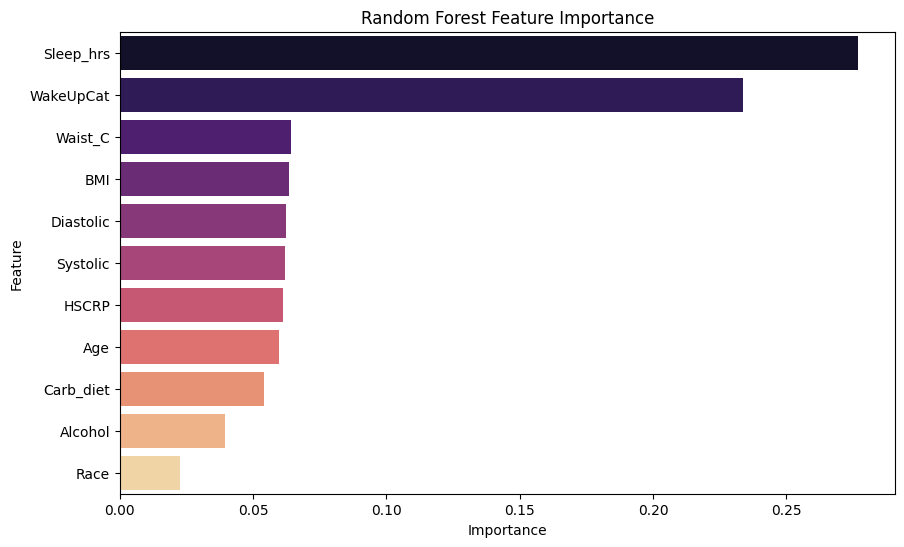

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importances from Random Forest
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Random Forest Feature Importance')
plt.show()

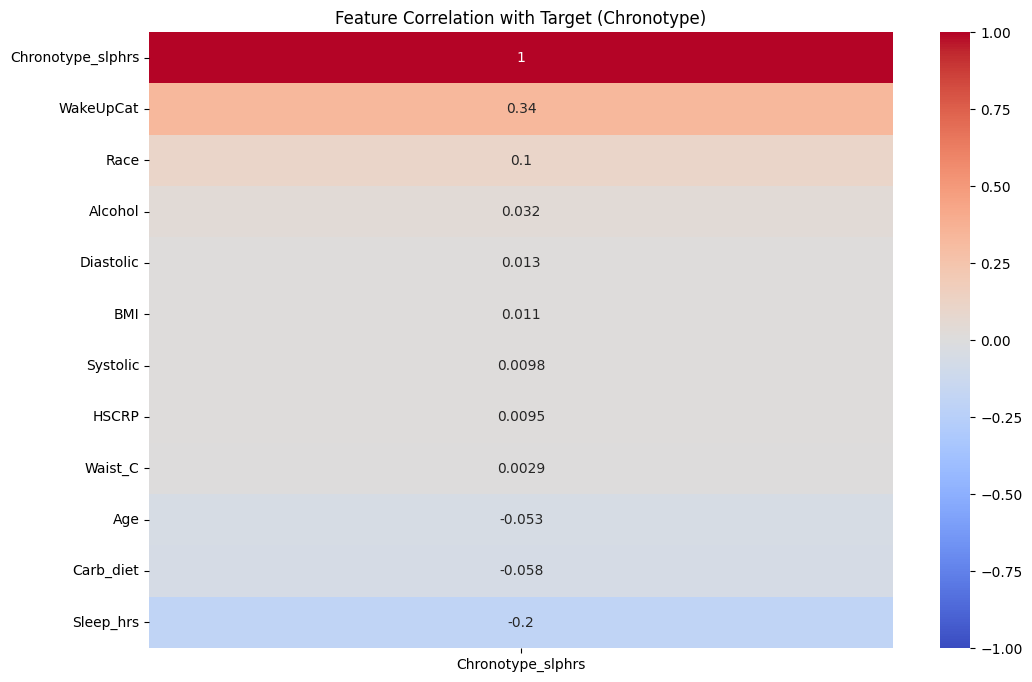

Potential Noisy Features (Importance < 2%):


,Feature,Importance


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = X.join(y).corr()
sns.heatmap(correlation_matrix[['Chronotype_slphrs']].sort_values(by='Chronotype_slphrs', ascending=False),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation with Target (Chronotype)')
plt.show()

# 2. Identify features with near-zero importance
low_importance_threshold = 0.02
noisy_candidates = feature_importance_df[feature_importance_df['Importance'] < low_importance_threshold]
print("Potential Noisy Features (Importance < 2%):")
display(noisy_candidates)

### Outlier Detection
We will use box plots to identify extreme values in our numerical features. In biological data, some 'outliers' are valid clinical variations, but extreme ones can negatively affect model convergence and accuracy.

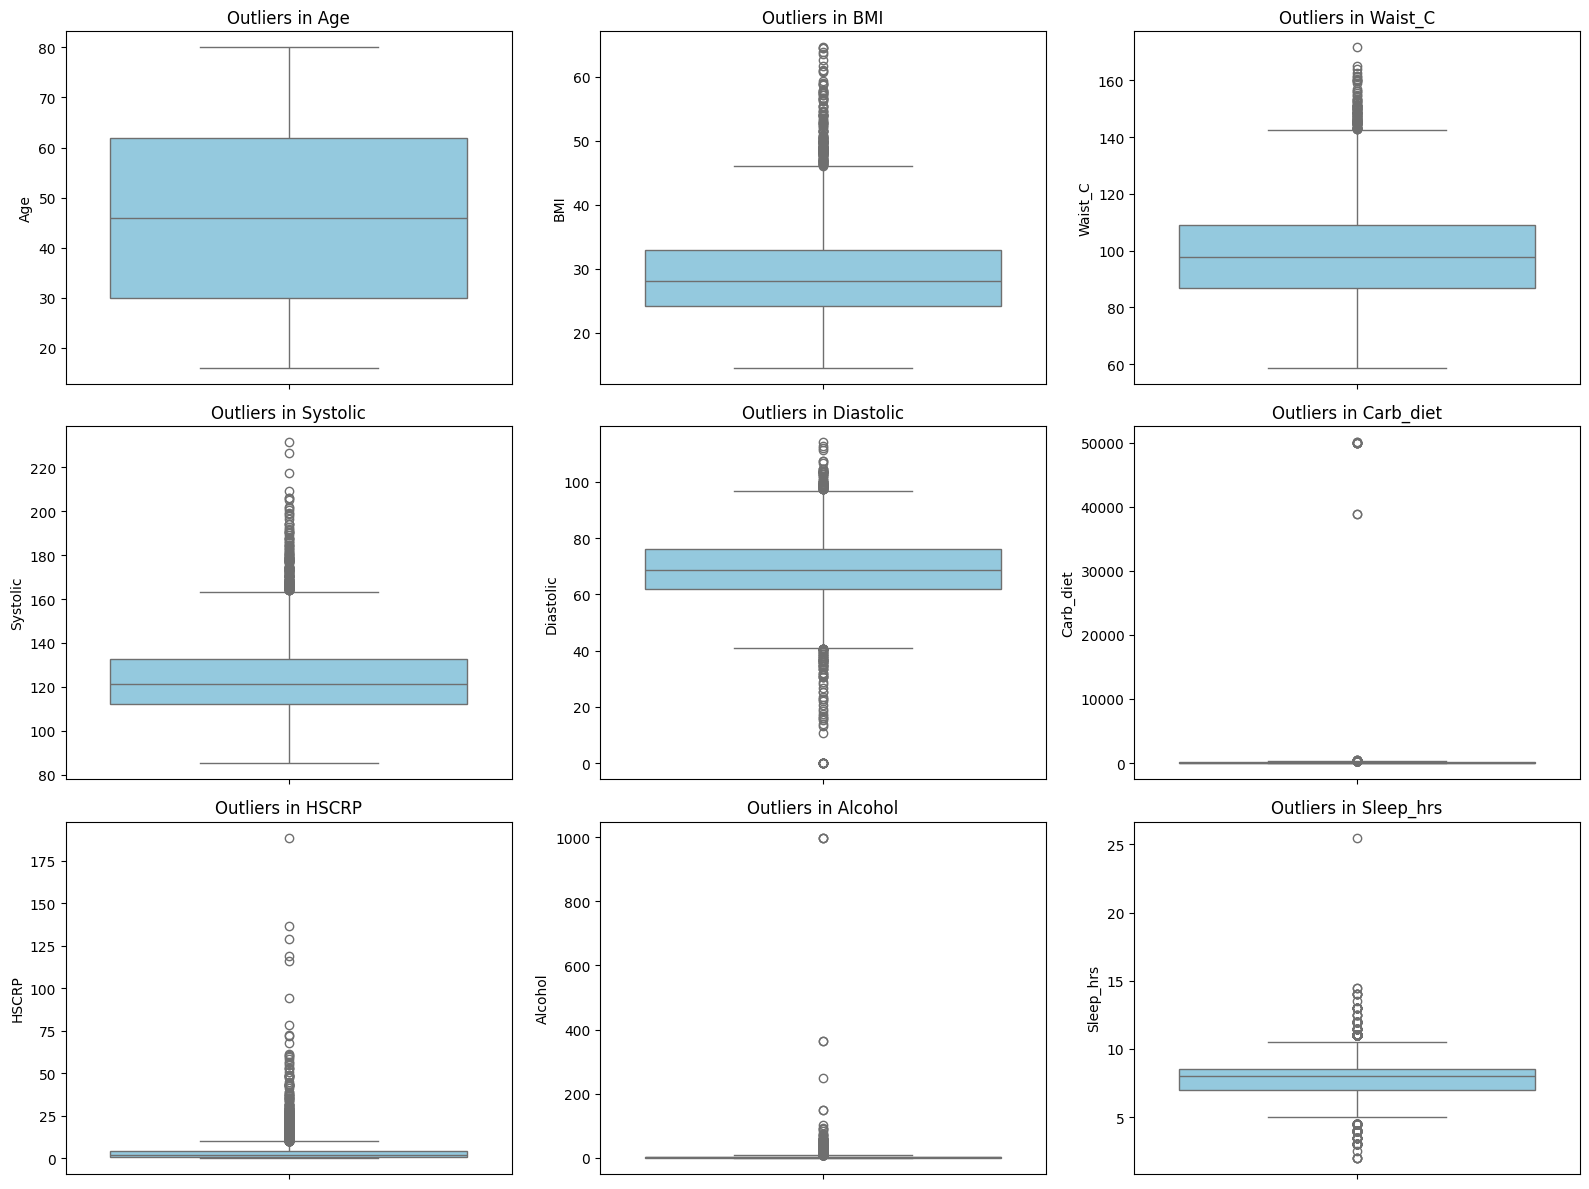

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns for outlier inspection
num_cols = ['Age', 'BMI', 'Waist_C', 'Systolic', 'Diastolic', 'Carb_diet', 'HSCRP', 'Alcohol', 'Sleep_hrs']

plt.figure(figsize=(16, 12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Outliers in {col}')

plt.tight_layout()
plt.show()

Based on the plots above, we can identify which features have the most significant outliers (e.g., `HSCRP` or `Alcohol` often have long tails). We can then decide whether to clip these values to a certain percentile or remove the extreme rows.

### Observation on Noisy Features
Features like `Gender` and `Smokingstatus` show extremely low correlation and importance. In biological data, these can sometimes act as noise, especially if their distribution is heavily skewed or unrelated to the circadian rhythm metrics we are predicting.

Would you like to try retraining the models without these low-importance features to see if it reduces overfitting?

### Model Ensembling: Stacking
Stacking uses a 'meta-model' to learn how to best combine the predictions of your top-performing models (RF, XGB, and NN).

In [15]:
# Retrain Stacking Ensemble on Outlier-Clipped Data
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Using existing rf_model configuration
rf_robust = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_split=5, class_weight='balanced', random_state=42)

estimators = [
    ('rf', rf_robust),
    ('xgb', XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss'))
]

stack_model_robust = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)

stack_model_robust.fit(X_train, y_train_encoded)
y_pred_robust = stack_model_robust.predict(X_test)

print("Stacking Ensemble Accuracy (Outliers Clipped):", accuracy_score(y_test_encoded, y_pred_robust))
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred_robust, target_names=le.classes_.astype(str)))


NameError: name 'StackingClassifier' is not defined

### K-Nearest Neighbors (KNN) Classifier with Hyperparameter Tuning

We will implement a K-Nearest Neighbors classifier, focusing on a *weighted* approach to improve performance. We'll use `GridSearchCV` to find the optimal number of neighbors (`n_neighbors`) and ensure the `weights` parameter is set to `'distance'` for weighted KNN. This approach gives closer neighbors a greater influence on the classification.

In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# Initialize KNN classifier
knn = KNeighborsClassifier()

# Define parameter grid for GridSearchCV
# We will explicitly set weights to 'distance' for weighted KNN
param_grid = {
    'n_neighbors': range(1, 21), # Test k from 1 to 20
    'weights': ['distance'] # For weighted KNN
}

# Setup GridSearchCV
# Using the scaled data as KNN is distance-based
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_nn_scaled, y_train_encoded)

# Best parameters and score
print("Best parameters for KNN:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

# Evaluate on the test set with the best estimator
best_knn_model = grid_search.best_estimator_
y_pred_knn = best_knn_model.predict(X_test_nn_scaled)

print("\nKNN Accuracy (Tuned, Weighted):", accuracy_score(y_test_encoded, y_pred_knn))
print("\nClassification Report for Tuned Weighted KNN:")
print(classification_report(y_test_encoded, y_pred_knn, target_names=le.classes_.astype(str)))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters for KNN: {'n_neighbors': 10, 'weights': 'distance'}
Best cross-validation accuracy: 0.5218139594309206

KNN Accuracy (Tuned, Weighted): 0.5268336314847942

Classification Report for Tuned Weighted KNN:
              precision    recall  f1-score   support

         1.0       0.44      0.19      0.27       156
         2.0       0.45      0.55      0.50       344
         3.0       0.58      0.75      0.65       443
         4.0       0.48      0.16      0.24        74
         5.0       0.83      0.25      0.38       101

    accuracy                           0.53      1118
   macro avg       0.56      0.38      0.41      1118
weighted avg       0.54      0.53      0.50      1118



### Improving KNN with SMOTE (Synthetic Minority Over-sampling Technique)

As discussed, the low accuracy, particularly for minority classes, could be due to class imbalance. We will apply SMOTE to the training data (`X_train_nn_scaled`, `y_train_encoded`) to create synthetic samples for the minority classes, thereby balancing the dataset. After oversampling, we will retrain the weighted KNN model with the same hyperparameter tuning approach.

In [20]:
from imblearn.over_sampling import SMOTE

print("Original training set shape:", X_train_nn_scaled.shape, y_train_encoded.shape)
print("Original class distribution (training):")
for i, count in enumerate(np.bincount(y_train_encoded)):
    print(f"Class {le.inverse_transform([i])[0]}: {count} samples")

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_nn_scaled, y_train_encoded)

print("\nResampled training set shape:", X_train_resampled.shape, y_train_resampled.shape)
print("Resampled class distribution (training):")
for i, count in enumerate(np.bincount(y_train_resampled)):
    print(f"Class {le.inverse_transform([i])[0]}: {count} samples")

# Re-initialize KNN classifier
knn_smote = KNeighborsClassifier()

# Define parameter grid for GridSearchCV (same as before)
param_grid_smote = {
    'n_neighbors': range(1, 21),
    'weights': ['distance']
}

# Setup GridSearchCV with resampled data
grid_search_smote = GridSearchCV(knn_smote, param_grid_smote, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_smote.fit(X_train_resampled, y_train_resampled)

# Best parameters and score for SMOTE-KNN
print("\nBest parameters for KNN (with SMOTE):", grid_search_smote.best_params_)
print("Best cross-validation accuracy (with SMOTE):", grid_search_smote.best_score_)

# Evaluate on the original (unresampled) test set with the best estimator
best_knn_smote_model = grid_search_smote.best_estimator_
y_pred_knn_smote = best_knn_smote_model.predict(X_test_nn_scaled)

print("\nKNN Accuracy (Tuned, Weighted, with SMOTE):", accuracy_score(y_test_encoded, y_pred_knn_smote))
print("\nClassification Report for Tuned Weighted KNN (with SMOTE):")
print(classification_report(y_test_encoded, y_pred_knn_smote, target_names=le.classes_.astype(str)))

Original training set shape: (4469, 11) (4469,)
Original class distribution (training):
Class 1.0: 641 samples
Class 2.0: 1325 samples
Class 3.0: 1727 samples
Class 4.0: 351 samples
Class 5.0: 425 samples

Resampled training set shape: (8635, 11) (8635,)
Resampled class distribution (training):
Class 1.0: 1727 samples
Class 2.0: 1727 samples
Class 3.0: 1727 samples
Class 4.0: 1727 samples
Class 5.0: 1727 samples
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters for KNN (with SMOTE): {'n_neighbors': 1, 'weights': 'distance'}
Best cross-validation accuracy (with SMOTE): 0.8337000579038796

KNN Accuracy (Tuned, Weighted, with SMOTE): 0.4928443649373882

Classification Report for Tuned Weighted KNN (with SMOTE):
              precision    recall  f1-score   support

         1.0       0.34      0.33      0.33       156
         2.0       0.50      0.46      0.48       344
         3.0       0.64      0.60      0.62       443
         4.0       0.28      0.36   

### Support Vector Machine (SVM) Classifier with Faster Hyperparameter Tuning

To address the long running time, we are re-running the SVM with a *reduced hyperparameter search space*. We will still explore both 'linear' and 'rbf' kernels but with fewer `C` (regularization) values and only the 'scale' option for `gamma` to speed up the `GridSearchCV` process.

In [25]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Initialize SVM classifier
svm = SVC(random_state=42)

# Define a reduced parameter grid for GridSearchCV for faster execution
param_grid_svm_fast = [
    {'C': [1, 10], 'kernel': ['linear']},
    {'C': [1, 10], 'gamma': ['scale'], 'kernel': ['rbf']}
]

# Setup GridSearchCV with the reduced grid
# Using the scaled data as SVMs are sensitive to feature scaling
grid_search_svm_fast = GridSearchCV(svm, param_grid_svm_fast, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_svm_fast.fit(X_train_nn_scaled, y_train_encoded)

# Best parameters and score
print("Best parameters for SVM (Faster Tune):", grid_search_svm_fast.best_params_)
print("Best cross-validation accuracy (Faster Tune):", grid_search_svm_fast.best_score_)

# Evaluate on the test set with the best estimator
best_svm_model_fast = grid_search_svm_fast.best_estimator_
y_pred_svm_fast = best_svm_model_fast.predict(X_test_nn_scaled)

print("\nSVM Accuracy (Faster Tuned):", accuracy_score(y_test_encoded, y_pred_svm_fast))
print("\nClassification Report for Faster Tuned SVM:")
print(classification_report(y_test_encoded, y_pred_svm_fast, target_names=le.classes_.astype(str)))

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best parameters for SVM (Faster Tune): {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validation accuracy (Faster Tune): 0.7279018265354948

SVM Accuracy (Faster Tuned): 0.740608228980322

Classification Report for Faster Tuned SVM:
              precision    recall  f1-score   support

         1.0       0.61      0.53      0.57       156
         2.0       0.69      0.76      0.72       344
         3.0       0.82      0.85      0.83       443
         4.0       0.74      0.70      0.72        74
         5.0       0.76      0.55      0.64       101

    accuracy                           0.74      1118
   macro avg       0.72      0.68      0.70      1118
weighted avg       0.74      0.74      0.74      1118



In [26]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Initialize SVM classifier
svm = SVC(random_state=42)

# Define a reduced parameter grid for GridSearchCV for faster execution
param_grid_svm_fast = [
    {'C': [1, 10], 'kernel': ['linear']},
    {'C': [1, 10], 'gamma': ['scale'], 'kernel': ['rbf']}
]

# Setup GridSearchCV with the reduced grid
# Using the scaled data as SVMs are sensitive to feature scaling
grid_search_svm_fast = GridSearchCV(svm, param_grid_svm_fast, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_svm_fast.fit(X_train_nn_scaled, y_train_encoded)

# Best parameters and score
print("Best parameters for SVM (Faster Tune, 'Race' removed):", grid_search_svm_fast.best_params_)
print("Best cross-validation accuracy (Faster Tune, 'Race' removed):", grid_search_svm_fast.best_score_)

# Evaluate on the test set with the best estimator
best_svm_model_fast = grid_search_svm_fast.best_estimator_
y_pred_svm_fast = best_svm_model_fast.predict(X_test_nn_scaled)

print("\nSVM Accuracy (Faster Tuned, 'Race' removed):", accuracy_score(y_test_encoded, y_pred_svm_fast))
print("\nClassification Report for Faster Tuned SVM ('Race' removed):")
print(classification_report(y_test_encoded, y_pred_svm_fast, target_names=le.classes_.astype(str)))

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best parameters for SVM (Faster Tune, 'Race' removed): {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validation accuracy (Faster Tune, 'Race' removed): 0.7279018265354948

SVM Accuracy (Faster Tuned, 'Race' removed): 0.740608228980322

Classification Report for Faster Tuned SVM ('Race' removed):
              precision    recall  f1-score   support

         1.0       0.61      0.53      0.57       156
         2.0       0.69      0.76      0.72       344
         3.0       0.82      0.85      0.83       443
         4.0       0.74      0.70      0.72        74
         5.0       0.76      0.55      0.64       101

    accuracy                           0.74      1118
   macro avg       0.72      0.68      0.70      1118
weighted avg       0.74      0.74      0.74      1118

